## Install the recsys_slates_dataset pip package


In [2]:
!pip install "cython<3.0.0" && pip install --no-build-isolation pyyaml==5.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.7 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cython
    Found existing installation: Cython 3.0.12
    Uninstalling Cython-3.0.12:
      Successfully uninstalled Cython-3.0.12
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.1/175.1 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyyaml: filename=PyYAML-5.4.1-cp312-cp312-linux_x86_64.whl size=45657 sha256=d093c9d60291922c59dda0ba9fbf0d84ca76f3c973bf99b0bf46d666ae86c625
  Stored in directory: /root/.cache/pip/wheels/db/55/e5/815110eef60d46b744555e67a31f4925346437926cedac7065
Successfully built pyyaml
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 6.0.3
    Uninstalling PyYAML-6.0.3:
      Successfully uninstalled PyYAML-6.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ad

In [3]:
!pip install recsys_slates_dataset -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
!cp -r /kaggle/input/datasets/ireneskvortsova/diploma-dataset /kaggle/working

In [ ]:
from torch.utils.data import Dataset, DataLoader
class SequentialDataset(Dataset):
    '''
     Note: displayType has been uncommented for future easy implementation.
    '''
    def __init__(self, data, sample_uniform_slate=False):

        self.data = data
        self.num_items = self.data['slate'].max()+1
        self.sample_uniform_slate = sample_uniform_slate
        print(f"Loading dataset with slate size={self.data['slate'].size()} and uniform candidate sampling={self.sample_uniform_slate}")

    def __getitem__(self, idx):
        batch = {key: val[idx] for key, val in self.data.items()}

        if self.sample_uniform_slate:
            # Sample actions uniformly:
            action = torch.randint_like(batch['slate'], low=3, high=self.num_items)

            # Add noclick action at pos0
            # and the actual click action at pos 1 (unless noclick):
            action[:,0] = 1
            clicked = batch['click']!=1
            action[:,1][clicked] = batch['click'][clicked]
            batch['slate'] = action
            # Set click idx to 0 if noclick, and 1 otherwise:
            batch['click_idx'] = clicked.long()

        return batch

    def __len__(self):
        return len(self.data['click'])

In [8]:
import numpy as np
import json
def load_dataloaders(data_dir= "dat",
                     batch_size=1024,
                     num_workers= 0,
                     sample_candidate_items=False,
                     valid_pct= 0.05,
                     test_pct= 0.05,
                     t_testsplit= 5,
                     limit_num_users=None,
                     seed=0):
    """
    Loads pytorch dataloaders to be used in training. If used with standard settings, the train/val/test split is equivalent to Eide et. al. 2021.

    Attributes:
      data_dir: [str] where download and store data if not already downloaded.
      batch_size: [int] Batch size given by dataloaders.
      num_workers: [int] How many threads should be used to prepare batches of data.
      sample_candidate_items: [int] Number of negative item examples sampled from the item universe for each interaction. If positive, the dataset provide an additional dictionary item "allitem". Often also called uniform candidate sampling. See Eide et. al. 2021 for more information.
      valid_pct: [float] Percentage of users allocated to validation dataset.
      test_pct: [float] Percentage of users allocated to test dataset.
      t_testsplit: [int] For users allocated to validation and test datasets, how many initial interactions should be part of the training dataset.
      limit_num_users: [int] For debugging purposes, only return some users.
      seed: [int] Seed used to sample users/items.

    """
    print('Load data..')
    with np.load("{}/data.npz".format(data_dir)) as data_np:
        data = {key: torch.tensor(val) for key, val in data_np.items()}
    print('Data loaded')

    if limit_num_users is not None:
        print("Limiting dataset to only return the first {} users.".format(limit_num_users))
        data = {key : val[:limit_num_users] for key, val in data.items()}

    with open('{}/ind2val.json'.format(data_dir), 'rb') as handle:
        # Use string2int object_hook found here: https://stackoverflow.com/a/54112705
        ind2val = json.load(
            handle,
            object_hook=lambda d: {
                int(k) if k.lstrip('-').isdigit() else k: v
                for k, v in d.items()
                }
            )

    num_users = len(data['click'])
    num_validusers = int(num_users * valid_pct)
    num_testusers = int(num_users * test_pct)
    torch.manual_seed(seed)
    perm_user = torch.randperm(num_users)
    valid_user_idx = perm_user[:num_validusers]
    test_user_idx  = perm_user[num_validusers:(num_validusers+num_testusers)]
    train_user_idx = perm_user[(num_validusers+num_testusers):]

    # Split dictionary into train/valid/test with a phase mask that shows which interactions are in different sets
    # (as some users have both train and valid data)
    data_train = data
    data_train['phase_mask'] = torch.ones_like(data['click']).bool()
    data_train['phase_mask'][test_user_idx,t_testsplit:]=False
    data_train['phase_mask'][valid_user_idx,t_testsplit:]=False

    data_valid = {key: val[valid_user_idx] for key, val in data.items()}
    data_valid['phase_mask'] = torch.zeros_like(data_valid['click']).bool()
    data_valid['phase_mask'][:,t_testsplit:] = True

    data_test = {key: val[test_user_idx] for key, val in data.items()}
    data_test['phase_mask'] = torch.zeros_like(data_test['click']).bool()
    data_test['phase_mask'][:,t_testsplit:] = True

    data_dicts = {
        "train" : data_train,
        "valid" : data_valid,
        "test" : data_test}

    datasets = {
        phase : SequentialDataset(data, sample_candidate_items)
        for phase, data in data_dicts.items()
        }


    # Build dataloaders for each data subset:
    dataloaders = {
        phase: DataLoader(ds, batch_size=batch_size, shuffle=(phase=="train"), num_workers=num_workers)
        for phase, ds in datasets.items()
    }
    for key, dl in dataloaders.items():
        print(
            "In {}: num_users: {}, num_batches: {}".format(key, len(dl.dataset), len(dl))
        )

    # Load item attributes:
    with np.load('{}/itemattr.npz'.format(data_dir), mmap_mode=None) as itemattr_file:
        itemattr = {key : val for key, val in itemattr_file.items()}

    return ind2val, itemattr, dataloaders

In [9]:
import torch
# from recsys_slates_dataset import dataset_torch
ind2val, itemattr, dataloaders = load_dataloaders(data_dir="/kaggle/working/diploma-dataset/")

print("Dictionary containing the dataloaders:")
print(dataloaders)

Load data..
Data loaded
Loading dataset with slate size=torch.Size([2277645, 20, 25]) and uniform candidate sampling=False
Loading dataset with slate size=torch.Size([113882, 20, 25]) and uniform candidate sampling=False
Loading dataset with slate size=torch.Size([113882, 20, 25]) and uniform candidate sampling=False
In train: num_users: 2277645, num_batches: 2225
In valid: num_users: 113882, num_batches: 112
In test: num_users: 113882, num_batches: 112
Dictionary containing the dataloaders:
{'train': <torch.utils.data.dataloader.DataLoader object at 0x7aa1a5b85760>, 'valid': <torch.utils.data.dataloader.DataLoader object at 0x7aa1a746eff0>, 'test': <torch.utils.data.dataloader.DataLoader object at 0x7aa1a62fff20>}


In [10]:
# Load interaction data
dat = dataloaders['train'].dataset.data

# Print dimensions of all arrays:
for key, val in dat.items():
  print(f"{key} : \t {val.size()}")

userId : 	 torch.Size([2277645])
click : 	 torch.Size([2277645, 20])
click_idx : 	 torch.Size([2277645, 20])
slate_lengths : 	 torch.Size([2277645, 20])
slate : 	 torch.Size([2277645, 20, 25])
interaction_type : 	 torch.Size([2277645, 20])
phase_mask : 	 torch.Size([2277645, 20])


In [11]:
print("Slate:")
print(dat['slate'][5,3])
print(" ")
print("Click:")
print(dat['click'][5,3])
print("Type of interaction: (1 implies search, see ind2val file)")
print(dat['interaction_type'][5,3])

Slate:
tensor([     1, 638995, 638947, 638711, 637590, 637930, 638894,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0])
 
Click:
tensor(637590)
Type of interaction: (1 implies search, see ind2val file)
tensor(1)


In [12]:
print("Click_idx:")
print(dat['click_idx'][5,3])
print("Slate lengths:")
print(dat['slate_lengths'][5,3])

Click_idx:
tensor(4)
Slate lengths:
tensor(7)


## IQL Experiment

In [ ]:
item2id

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

UNK_ID = 2

class SlatesDataset(Dataset):
    def __init__(self, user_seqs, user_clicks, max_len=25, item2id=dict(), id2item=dict(), append_items=True):
        self.samples = []
        self.max_len = max_len
        self.item_dim = 0
        self.item2id = item2id
        self.id2item = id2item

        for user_sequences, user_clks in tqdm(zip(user_seqs, user_clicks)):
            for seq_original, seq_click in zip(user_sequences, user_clks):
                correct_seq = True
                seq_transformed = []
                seq_clicks = []
                for s in seq_original:
                    if s.item() >= 3 and s.item() not in self.item2id:
                        if append_items:
                            self.item_dim += 1
                            self.item2id[s.item()] = self.item_dim
                        else:
                            correct_seq = False
                            break
                        if s.item() == 0:
                            break
                    if s.item() >= 3:
                        seq_transformed.append(self.item2id[s.item()])
                        seq_clicks.append(seq_click == s.item())
                if not correct_seq:
                    continue

                if sum(seq_clicks) == 0:
                    continue
                for i in range(3, len(seq_transformed)):
                    item = seq_transformed[i]
                    if item == 0:
                        break
                    state = seq_transformed[:i]
                    clicks = seq_clicks[:i]
                    action = seq_transformed[i]
                    next_state = seq_transformed[:i+1]
                    candidates = seq_transformed[i:]
                    reward = 1.0
                    done = 1.0 if (i == len(seq_transformed) - 1) else 0.0
                    # print("appending slate")
                    self.samples.append((state, action, reward, next_state, clicks, done, candidates))

    def __len__(self):
        return len(self.samples)

    def transform_original_user_seq(self, user_sequences):
        user_seqs_transformed = []
        for seq_original in user_sequences:
            correct_seq = True
            seq_transformed = []
            for s in seq_original:
                if s not in self.item2id:
                    correct_seq = False
                    print("Item s is not in self.item2id")
                    break
                seq_transformed.append(self.item2id[s.item()])
            if correct_seq:
                user_seqs_transformed.append(seq_transformed)
        return user_seqs_transformed

    def get_item2id(self):
        return self.item2id

    def get_id2item(self):
        return self.id2item

    def get_item_dim(self):
        return self.item_dim

    def pad(self, x):
        res = torch.zeros(self.max_len, dtype=torch.long)
        length = min(len(x), self.max_len)
        res[-length:] = torch.tensor(x[-length:], dtype=torch.long)
        return res

    def pad_candidates(self, x):
        res = torch.zeros(self.max_len, dtype=torch.long)
        length = min(len(x), self.max_len)
        res[:length] = torch.tensor(x[:length], dtype=torch.long)
        return res

    def __getitem__(self, idx):
        s, a, r, ns, clicks,d, cands = self.samples[idx]
        return {
            'state': self.pad(s),
            'action': torch.tensor(a, dtype=torch.long),
            'reward': torch.tensor(r, dtype=torch.float32),
            'next_state': self.pad(ns),
            'terminal': torch.tensor(d, dtype=torch.float32),
            'clicks': self.pad(clicks),
            'candidates': self.pad_candidates(cands),
        }


In [ ]:
reward_model, item2id = load_reward_model("/kaggle/input/datasets/ireneskvortsova/reward-model-500k-trained/reward_model_ep19.pth", device)

RewardModel loaded from /kaggle/input/datasets/ireneskvortsova/reward-model-500k-trained/reward_model_ep19.pth  (item_dim=1245403, hidden=128)


In [9]:
slates_len = 200_000 #2_277_645 #500_000
slates_ds = SlatesDataset(dat['slate'][:slates_len], max_len=25)
print(len(slates_ds))

100%|██████████| 200000/200000 [02:40<00:00, 1242.36it/s]

346262


In [ ]:
from torch.utils.data import random_split

n = len(slates_ds)
n_test = int(0.1 * n)
train_ds, test_ds = random_split(slates_ds, [n - n_test, n_test])
train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

In [68]:
print(len(test_ds))

392225


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
class IQLAgent(nn.Module):
  def __init__(self, item_dim, num_categories, hidden_dim=64, padding_idx=0):
      super().__init__()
      self.padding_idx = padding_idx
      self.item_dim = item_dim

      self.embedding = nn.Embedding(item_dim + 1, hidden_dim, padding_idx=padding_idx)
      self.item_encoder = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

      cat_dim = hidden_dim // 4
      self.cat_embedding = nn.Embedding(num_categories + 2, cat_dim, padding_idx=0)
      self.cat_encoder = nn.GRU(cat_dim, cat_dim, batch_first=True)

      state_dim = hidden_dim + cat_dim

      self.v_net = nn.Sequential(
          nn.Linear(state_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
      )
      self.q_net = nn.Sequential(
          nn.Linear(state_dim + hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
      )
      self.q_target = copy.deepcopy(self.q_net)
      for p in self.q_target.parameters():
          p.requires_grad = False

      self.policy_head = nn.Linear(state_dim, hidden_dim, bias=False)

      self.register_buffer('item_categories', torch.zeros(item_dim + 1, dtype=torch.long))

  def get_state_repr(self, states_seq):
      item_emb = self.embedding(states_seq)
      _, h_item = self.item_encoder(item_emb)
      cat_seq = self.item_categories[states_seq]
      cat_emb = self.cat_embedding(cat_seq)
      _, h_cat = self.cat_encoder(cat_emb)
      return torch.cat([h_item.squeeze(0), h_cat.squeeze(0)], dim=-1)

  def score_candidates(self, state_emb, candidates):
      cand_emb = self.embedding(candidates)
      s_exp = state_emb.unsqueeze(1).expand_as(cand_emb)
      scores = self.q_net(torch.cat([s_exp, cand_emb], dim=-1)).squeeze(-1)
      return scores.masked_fill(candidates == self.padding_idx, float('-inf'))

  def sync_target(self, alpha=0.005):
      for p, tp in zip(self.q_net.parameters(), self.q_target.parameters()):
          tp.data.copy_(alpha * p.data + (1 - alpha) * tp.data)

In [72]:
item_dim = len(slates_ds.get_item2id())
print(item_dim)

1245403


In [79]:
num_categories = 290 #int(itemattr['category'].max()) # 290
item_cat_tensor = torch.zeros(item_dim + 1, dtype=torch.long)
for original_id, remapped_id in slates_ds.get_item2id().items():
  item_cat_tensor[remapped_id] = int(itemattr['category'][original_id]) + 1

In [ ]:
import torch
import torch.nn.functional as F

def expectile_loss(diff, tau=0.8):
    weight = torch.where(diff < 0, 1 - tau, tau)
    return (weight * (diff**2)).mean()

def train_step(agent, batch, optimizer_v, optimizer_q, optimizer_p,
               gamma=0.99, tau=0.8, beta=3.0, alpha=0.005, neg_k=512):
    with torch.no_grad():
        s_emb = agent.get_state_repr(batch['state'])
        a_emb = agent.embedding(batch['action'])
        q_hat = agent.q_target(torch.cat([s_emb, a_emb], dim=-1)).squeeze(-1)

    v_val  = agent.v_net(s_emb)
    v_loss = expectile_loss(q_hat - v_val, tau=tau)
    optimizer_v.zero_grad(); v_loss.backward()
    torch.nn.utils.clip_grad_norm_(agent.v_net.parameters(), 1.0)
    optimizer_v.step()

    s_emb = agent.get_state_repr(batch['state'])
    a_emb = agent.embedding(batch['action'])
    with torch.no_grad():
        ns_emb   = agent.get_state_repr(batch['next_state'])
        next_v   = agent.v_net(ns_emb)
        normed_r = batch['reward'].view(-1) * (1 - gamma)
        q_backup = normed_r + gamma * (1 - batch['terminal'].view(-1)) * next_v.squeeze(-1)
    q_val  = agent.q_net(torch.cat([s_emb, a_emb], dim=-1)).squeeze(-1)
    q_loss = F.mse_loss(q_val, q_backup)
    optimizer_q.zero_grad(); q_loss.backward()
    torch.nn.utils.clip_grad_norm_(
        list(agent.q_net.parameters()) +
        list(agent.item_encoder.parameters()) +
        list(agent.cat_encoder.parameters()) +
        list(agent.cat_embedding.parameters()) +
        list(agent.embedding.parameters()), 1.0)
    optimizer_q.step()
    agent.sync_target(alpha=alpha)

    B = batch['action'].shape[0]
    device = batch['action'].device

    with torch.no_grad():
        s_emb_p = agent.get_state_repr(batch['state'])
        a_emb_p = agent.embedding(batch['action'])
        q_adv = agent.q_target(torch.cat([s_emb_p, a_emb_p], dim=-1)).squeeze(-1)
        v_adv = agent.v_net(s_emb_p).squeeze(-1)
        weights = torch.exp(beta * (q_adv - v_adv)).clamp(max=100.0)

        pos_emb_p  = agent.embedding(batch['action']) # [B, H]
        cands = batch['candidates'] # [B, max_len]
        neg_ids = cands[:, 1:] # [B, max_len-1]
        neg_mask = (neg_ids == 0)
        if neg_mask.all():
            neg_ids  = torch.randint(1, agent.item_dim + 1, (B, neg_k), device=device)
            neg_mask = torch.zeros(B, neg_k, dtype=torch.bool, device=device)
        neg_embs_p = agent.embedding(neg_ids.clamp(min=0)) # [B, K, H]

    state_proj = agent.policy_head(s_emb_p) # [B, H]
    H = state_proj.shape[-1]
    pos_score  = (state_proj * pos_emb_p.detach()).sum(-1, keepdim=True) / (H ** 0.5)
    neg_scores = torch.bmm(neg_embs_p.detach(),
                           state_proj.unsqueeze(-1)).squeeze(-1) / (H ** 0.5)
    neg_scores.masked_fill_(neg_mask, float('-inf'))

    all_scores = torch.cat([pos_score, neg_scores], dim=-1)
    log_prob = F.log_softmax(all_scores, dim=-1)[:, 0]
    p_loss = -(weights * log_prob).mean()

    optimizer_p.zero_grad(); p_loss.backward()
    torch.nn.utils.clip_grad_norm_(agent.policy_head.parameters(), 1.0)
    optimizer_p.step()

    return (v_loss + q_loss + p_loss).item(), q_loss.item(), v_loss.item(), p_loss.item()


In [17]:
itemattr['category'].size

1311775

In [ ]:
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
agent = IQLAgent(item_dim, num_categories=290, hidden_dim=128).to(device)
agent.item_categories.copy_(item_cat_tensor.to(device))
agent.embedding.weight.data.copy_(reward_model.item_emb.weight.data)
agent.embedding.weight.requires_grad=False
optimizer_v = torch.optim.Adam(agent.v_net.parameters(), lr=3e-4)
optimizer_p = torch.optim.Adam(agent.policy_head.parameters(), lr=3e-4)
optimizer_q = torch.optim.Adam(
    list(agent.q_net.parameters()) +
    list(agent.item_encoder.parameters()) +
    list(agent.cat_encoder.parameters()) +
    list(agent.cat_embedding.parameters()),
    lr=3e-4
)

losses, q_losses, v_losses, p_losses = [], [], [], []
i = 0
print(f'Training with slates_len={slates_len}, item_dim={item_dim}')
NUM_EPOCHS = 10
for epoch in range(NUM_EPOCHS):
    print(f'~~~~~~EPOCH={epoch}~~~~~')
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items() if k != "clicks"}
        total_loss, q_loss, v_loss, p_loss = train_step(
            agent, batch, optimizer_v, optimizer_q, optimizer_p, tau=0.9, gamma=0.9
        )
        losses.append(total_loss); q_losses.append(q_loss)
        v_losses.append(v_loss);   p_losses.append(p_loss)
        if i % 200 == 0:
            print(f'Step {i}:', total_loss, q_loss, v_loss, p_loss)
        i += 1


Using device: cuda
Training with slates_len=50000, item_dim=1245403
~~~~~~EPOCH=0~~~~~
Step 0: 2.3867359161376953 0.02832401916384697 0.025474855676293373 2.332937002182007
Step 200: 1.2627760171890259 0.013007396832108498 0.001783430459909141 1.2479852437973022
Step 400: 1.2875667810440063 0.015598397701978683 0.0010765085462480783 1.2708919048309326
Step 600: 1.2929562330245972 0.01928023248910904 0.0010535484179854393 1.2726224660873413
Step 800: 1.292244791984558 0.0210251584649086 0.001231808913871646 1.2699878215789795
Step 1000: 1.299412488937378 0.021580176427960396 0.0016249250620603561 1.276207447052002
Step 1200: 1.2241350412368774 0.029859771952033043 0.0019251902122050524 1.1923500299453735
Step 1400: 1.3234461545944214 0.02733784168958664 0.0022147223353385925 1.293893575668335
Step 1600: 1.272312879562378 0.031867604702711105 0.0024120034649968147 1.2380332946777344
Step 1800: 1.2651461362838745 0.03410552442073822 0.0024298017378896475 1.2286107540130615
Step 2000: 1.27

KeyboardInterrupt: 

Text(0.5, 1.0, 'P loss')

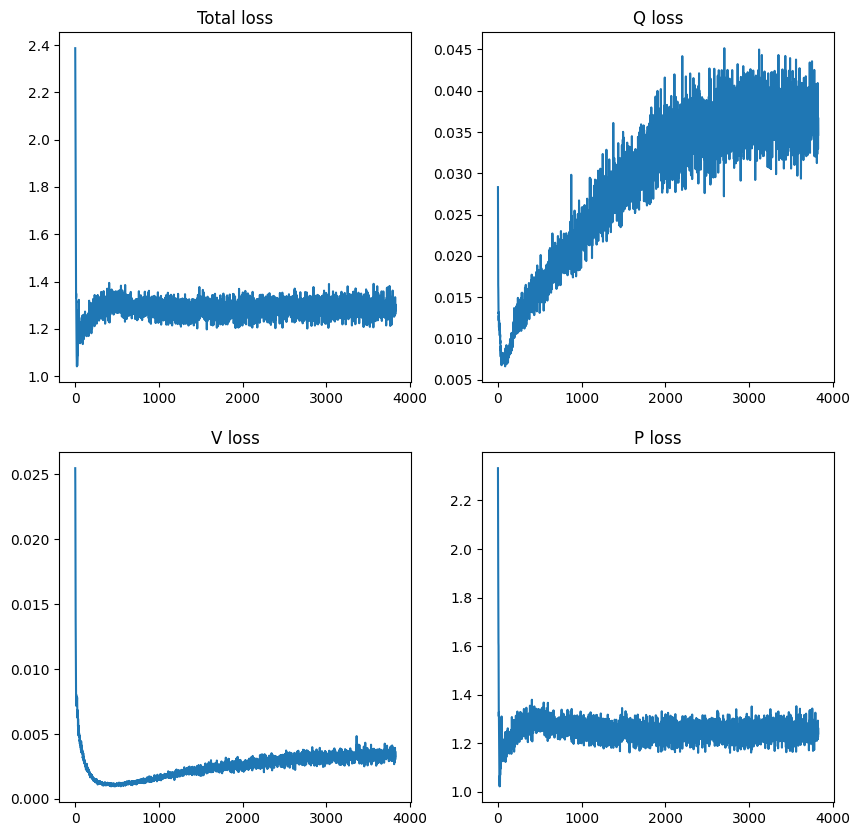

In [90]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0][0].plot(losses)
axes[0][0].set_title('Total loss')
axes[0][1].plot(q_losses)
axes[0][1].set_title('Q loss')
axes[1][0].plot(v_losses)
axes[1][0].set_title('V loss')
axes[1][1].plot(p_losses)
axes[1][1].set_title('P loss')

Running t-SNE on 10000 items (dim=128)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 0.699s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.780244
[t-SNE] KL divergence after 250 iterations with early exaggeration: 93.944489
[t-SNE] KL divergence after 1000 iterations: 4.585649
Done.


/tmp/ipykernel_57/4109255929.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = cm.get_cmap('tab20', TOP_K_CATS)


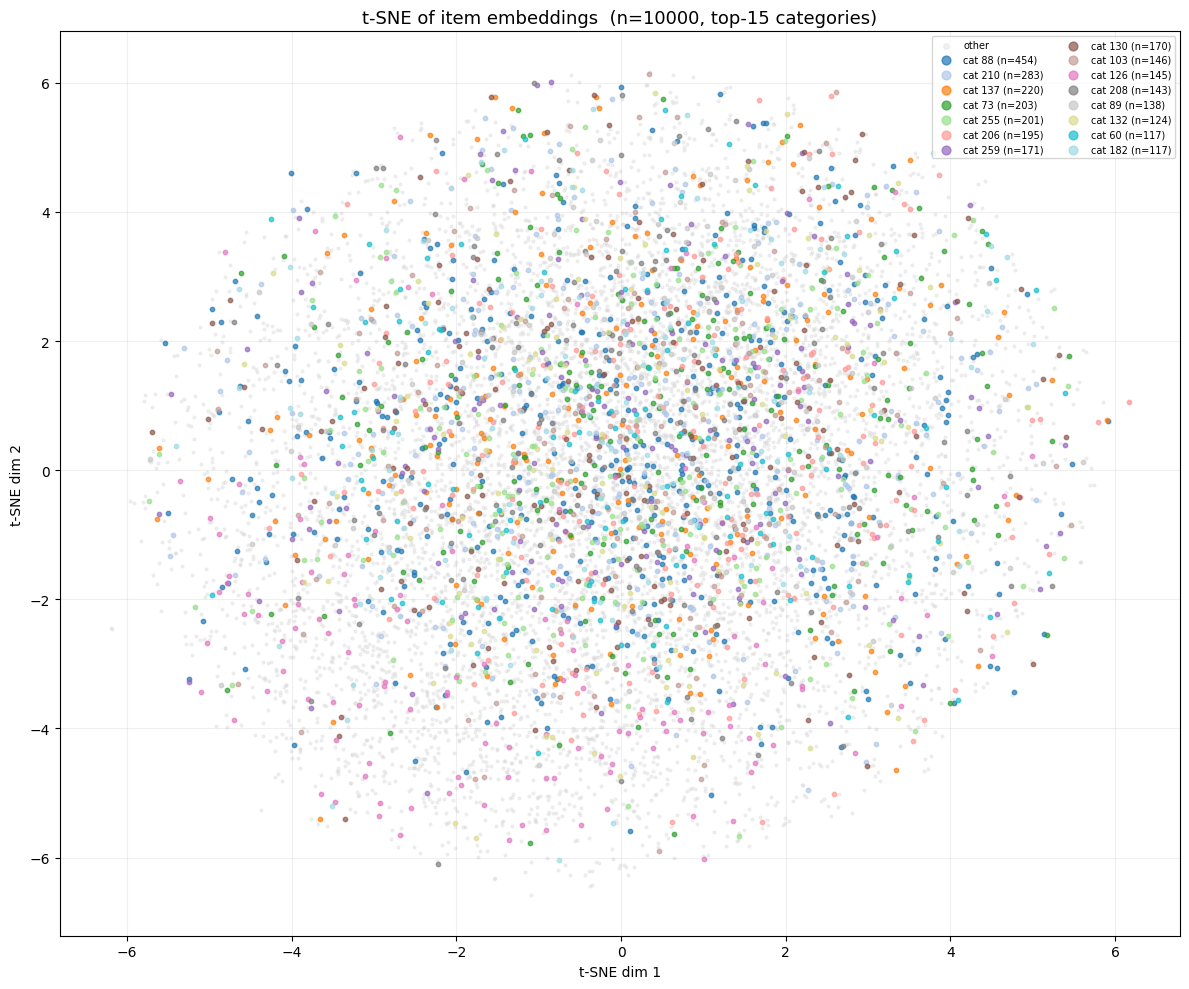

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE

N_ITEMS = 10000
TOP_K_CATS = 15
TSNE_PERP = 40
RANDOM_SEED = 42

all_ids = torch.arange(1, agent.item_dim + 1)

cats_all = item_cat_tensor[all_ids].cpu()
valid = (cats_all > 0).nonzero(as_tuple=True)[0]

rng = np.random.default_rng(RANDOM_SEED)
sample_i = rng.choice(len(valid), size=min(N_ITEMS, len(valid)), replace=False)
sampled_positions = valid[sample_i]
sampled_ids = all_ids[sampled_positions]
sampled_cats = cats_all[sampled_positions].numpy()

reward_model.eval()
with torch.no_grad():
    embs = reward_model.item_emb(sampled_ids.to(device)).cpu().numpy()  # [N, H]

print(f"Running t-SNE on {len(embs)} items (dim={embs.shape[1]})...")
tsne = TSNE(n_components=2, perplexity=TSNE_PERP, random_state=RANDOM_SEED,
              n_iter=1000, verbose=1)
coords = tsne.fit_transform(embs)
print("Done.")

unique_cats, counts = np.unique(sampled_cats, return_counts=True)
top_cats = unique_cats[np.argsort(-counts)][:TOP_K_CATS]

cmap = cm.get_cmap('tab20', TOP_K_CATS)
cat2col = {cat: cmap(i) for i, cat in enumerate(top_cats)}
colors = [cat2col.get(c, (0.7, 0.7, 0.7, 0.3)) for c in sampled_cats]

fig, ax = plt.subplots(figsize=(12, 10))

other_mask = np.array([c not in cat2col for c in sampled_cats])
ax.scatter(coords[other_mask, 0], coords[other_mask, 1],
           c='lightgray', s=4, alpha=0.3, label='other', zorder=1)

for cat in top_cats:
    mask = (sampled_cats == cat)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[cat2col[cat]], s=10, alpha=0.7,
               label=f'cat {int(cat)} (n={mask.sum()})', zorder=2)

ax.set_title(f't-SNE of item embeddings  (n={len(embs)}, top-{TOP_K_CATS} categories)',
             fontsize=13)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(loc='upper right', fontsize=7, markerscale=2,
          ncol=2, framealpha=0.8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# Pretraining

In [188]:
len(item2id.keys())

1245403

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random

class PretrainDataset(Dataset):
      """One sample = one slate (list of item ids), mapped through item2id."""
      def __init__(self, user_seqs, item2id, min_slate=2):
          self.slates = []
          for slates in tqdm(user_seqs):
              for i in range(1, len(slates)):
                  slate = slates[i]
                  mapped = [item2id[x.item()] for x in slate if x.item() in item2id]
                  if len(mapped) >= min_slate:
                      self.slates.append(mapped)

      def __len__(self):
          return len(self.slates)

      def __getitem__(self, idx):
          return self.slates[idx]

def category_loss(embedding, category_head, item_ids, item_categories):
  item_ids = item_ids[item_ids > 0]
  if item_ids.numel() == 0:
      return torch.tensor(0.0, requires_grad=True)
  emb = embedding(item_ids) # [N, H]
  logits = category_head(emb) # [N, num_cat]
  labels = item_categories[item_ids] # [N]
  return F.cross_entropy(logits, labels)

def infonce_loss_batch(embedding, batch_slates, temperature=0.07):
      all_ids, slate_idx = [], []
      for i, slate in enumerate(batch_slates):
          ids = [x for x in slate if x > 0]
          if len(ids) >= 2:
              all_ids.extend(ids)
              slate_idx.extend([i] * len(ids))

      if len(all_ids) < 2:
          return torch.tensor(0.0, device=embedding.weight.device, requires_grad=True)

      ids_t = torch.tensor(all_ids,   dtype=torch.long, device=embedding.weight.device)
      slate_t = torch.tensor(slate_idx, dtype=torch.long, device=embedding.weight.device)

      emb = F.normalize(embedding(ids_t), dim=-1) # [N, H]
      N = emb.size(0)

      sim = torch.mm(emb, emb.t()) / temperature # [N, N]

      eye = torch.eye(N, dtype=torch.bool, device=emb.device)
      same = (slate_t.unsqueeze(0) == slate_t.unsqueeze(1)) & ~eye

      has_pos = same.any(dim=1)
      if not has_pos.any():
          return torch.tensor(0.0, device=emb.device, requires_grad=True)

      log_denom = torch.logsumexp(sim.masked_fill(eye, float('-inf')), dim=1)  # [N]

      pos_count = same.float().sum(dim=1).clamp(min=1)
      pos_sum = (sim * same.float()).sum(dim=1)

      loss = -(pos_sum / pos_count - log_denom)[has_pos].mean()
      return loss

In [ ]:
def pretrain_category(agent, loader, device, num_epochs=3, lr=1e-3):
      """Stage 1: category prediction."""
      num_categories = int(item_cat_tensor.max().item()) + 1
      category_head = nn.Linear(agent.embedding.embedding_dim, num_categories).to(device)

      optimizer = torch.optim.Adam(
          list(agent.embedding.parameters()) + list(category_head.parameters()),
          lr=lr
      )

      agent.train()
      for epoch in range(num_epochs):
          total_loss, steps = 0.0, 0
          for batch in tqdm(loader):
              optimizer.zero_grad()
              all_ids = []
              for slate in batch:
                  all_ids.extend(slate)
              if not all_ids:
                  continue
              item_ids = torch.tensor(all_ids, dtype=torch.long, device=device)
              loss = category_loss(agent.embedding, category_head, item_ids, item_cat_tensor.to(device))
              loss.backward()
              optimizer.step()
              total_loss += loss.item()
              steps += 1
          print(f"[Category] epoch {epoch+1}/{num_epochs}  loss={total_loss/max(steps,1):.4f}")

      return category_head  # return in case you want to reuse it


def pretrain_cooccurrence(agent, loader, device, num_epochs=3, lr=1e-3, temperature=0.07):
  optimizer = torch.optim.Adam(agent.embedding.parameters(), lr=lr)
  agent.train()
  for epoch in range(num_epochs):
      total_loss, steps = 0.0, 0
      for batch in tqdm(loader):
          optimizer.zero_grad()
          loss = infonce_loss_batch(agent.embedding, batch, temperature=temperature)
          if not loss.requires_grad:
              continue
          loss.backward()
          optimizer.step()
          total_loss += loss.item()
          steps += 1
      print(f"[Co-occur] epoch {epoch+1}/{num_epochs}  loss={total_loss/max(steps,1):.4f}")


def pretrain_next_item(agent, loader_padded, device,
                     num_epochs=5, lr=3e-3, temperature=0.1):
  optimizer = torch.optim.Adam(agent.item_encoder.parameters(), lr=lr)
  agent.train()

  for epoch in range(num_epochs):
      total_loss, steps = 0.0, 0
      for padded, lengths in tqdm(loader_padded):
          mask = lengths >= 2
          if not mask.any():
              continue
          padded = padded[mask].to(device)
          lengths = lengths[mask]
          input_seq = padded[:, :-1]
          input_lens = (lengths - 1).clamp(min=1)
          target_ids = padded[torch.arange(padded.size(0), device=device),
                              (lengths - 1).to(device)]

          emb = agent.embedding(input_seq)
          packed = nn.utils.rnn.pack_padded_sequence(emb, input_lens.cpu(), batch_first=True, enforce_sorted=False)
          _, h = agent.item_encoder(packed)
          h = h.squeeze(0) # [B, H]

          target_emb = agent.embedding(target_ids) # [B, H]

          sim = torch.mm(F.normalize(h, dim=-1), F.normalize(target_emb, dim=-1).t()) / temperature
          labels = torch.arange(sim.size(0), device=device)
          loss = F.cross_entropy(sim, labels)

          optimizer.zero_grad()
          loss.backward()
          torch.nn.utils.clip_grad_norm_(agent.item_encoder.parameters(), 1.0)
          optimizer.step()
          total_loss += loss.item()
          steps += 1

      print(f"[NextItem] epoch {epoch+1}/{num_epochs}  "
            f"loss={total_loss/max(steps,1):.4f}  "
            f"(random baseline={torch.log(torch.tensor(float(padded.size(0)))).item():.2f})")

In [ ]:
def collate_slates_padded(batch):
      lengths = torch.tensor([len(s) for s in batch], dtype=torch.long)
      max_len = int(lengths.max())
      padded = torch.zeros(len(batch), max_len, dtype=torch.long)
      for i, slate in enumerate(batch):
          padded[i, :len(slate)] = torch.tensor(slate, dtype=torch.long)
      return padded, lengths

def collate_slates(batch):
          return batch

def pretrain_embeddings(agent, user_seqs, item2id, device,
                          batch_size=256,
                          cat_epochs=3, cat_lr=1e-3,
                          coo_epochs=3, coo_lr=1e-3,
                          next_item_epochs=5, ni_lr =3e-3,
                          temperature=0.07):
      dataset = PretrainDataset(user_seqs, item2id)
      print(f"Pretraining on {len(dataset)} slates")

      loader_padded = DataLoader(dataset, batch_size=batch_size,
                                 shuffle=True, collate_fn=collate_slates_padded)
      loader_list   = DataLoader(dataset, batch_size=batch_size,
                                 shuffle=True, collate_fn=collate_slates)

      print("\n=== Stage 3: Next-item prediction ===")
      pretrain_next_item(agent, loader_padded, device, num_epochs=next_item_epochs, lr=ni_lr)
      for p in agent.item_encoder.parameters():
          p.requires_grad_(False)
      print("\nEmbedding + item_encoder frozen. Pretraining complete.")


In [283]:
agent = IQLAgent(item_dim, hidden_dim=128).to(device)
agent.item_categories.copy_(item_cat_tensor.to(device))
# agent.embedding.weight.data.copy_(reward_model.item_emb.weight.data)
# agent.embedding.weight.requires_grad=False

tensor([  0, 103, 202,  ..., 174, 208, 124], device='cuda:0')

In [218]:
print(agent.item_categories.max()), device

tensor(290, device='cuda:0')


(None, device(type='cuda'))

In [284]:
pretrain_embeddings(agent, dat['slate'][:100000], item2id=item2id, device=device,
                      cat_epochs=5, coo_epochs=10, next_item_epochs=10)

100%|██████████| 100000/100000 [01:44<00:00, 956.02it/s]


Pretraining on 1446182 slates

=== Stage 1: Category pretraining ===


100%|██████████| 5650/5650 [02:40<00:00, 35.25it/s]


[Category] epoch 1/5  loss=2.5297


100%|██████████| 5650/5650 [02:40<00:00, 35.31it/s]


...

100%|██████████| 5650/5650 [02:47<00:00, 33.83it/s]


[Co-occur] epoch 9/10  loss=3.9735


100%|██████████| 5650/5650 [02:47<00:00, 33.83it/s]

[Co-occur] epoch 10/10  loss=3.8794

Embedding frozen.

=== Stage 3: Next-item prediction ===


TypeError: pretrain_next_item() got an unexpected keyword argument 'next_item_epochs'

In [297]:
pretrain_embeddings(agent, dat['slate'][:100000], item2id=item2id, device=device,
                      cat_epochs=5, coo_epochs=10, next_item_epochs=10)

100%|██████████| 100000/100000 [01:29<00:00, 1112.94it/s]


Pretraining on 1446182 slates

=== Stage 3: Next-item prediction ===


100%|██████████| 5650/5650 [00:47<00:00, 118.93it/s]


[NextItem] epoch 1/10  loss=1.0324  (random baseline=3.64)


100%|██████████| 5650/5650 [00:46<00:00, 120.24it/s]


...

[NextItem] epoch 8/10  loss=1.0299  (random baseline=3.64)


100%|██████████| 5650/5650 [00:47<00:00, 119.28it/s]


[NextItem] epoch 9/10  loss=1.0302  (random baseline=3.64)


100%|██████████| 5650/5650 [00:47<00:00, 119.44it/s]


[NextItem] epoch 10/10  loss=1.0300  (random baseline=3.64)

Embedding + item_encoder frozen. Pretraining complete.


In [ ]:
for p in agent.item_encoder.parameters():
          p.requires_grad_(True)
pretrain_embeddings(agent, dat['slate'][:100000], item2id=item2id, device=device,
                      cat_epochs=5, coo_epochs=10, next_item_epochs=20)

100%|██████████| 100000/100000 [01:31<00:00, 1095.12it/s]


Pretraining on 1446182 slates

=== Stage 3: Next-item prediction ===


100%|██████████| 5650/5650 [00:50<00:00, 112.67it/s]


[NextItem] epoch 1/20  loss=1.0778  (random baseline=3.64)


100%|██████████| 5650/5650 [00:53<00:00, 106.34it/s]


...

[NextItem] epoch 5/20  loss=1.0797  (random baseline=3.64)


100%|██████████| 5650/5650 [00:49<00:00, 113.62it/s]


[NextItem] epoch 6/20  loss=1.0800  (random baseline=3.64)


  5%|▌         | 283/5650 [00:02<00:48, 110.57it/s]


KeyboardInterrupt: 

In [ ]:
for p in agent.item_encoder.parameters():
    p.requires_grad_(False)

In [ ]:
torch.save(agent.embedding.state_dict(), 'iql_item_embeddings_good_tsne3.pt')
torch.save(agent.item_encoder.state_dict(), 'iql_item_encoder_tsne3.pt')

Running t-SNE on 10000 items (dim=128)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 0.743s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 3.058077
[t-SNE] KL divergence after 250 iterations with early exaggeration: 91.852631
[t-SNE] KL divergence after 1000 iterations: 3.352965
Done.


/tmp/ipykernel_57/139137979.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = cm.get_cmap('tab20', TOP_K_CATS)


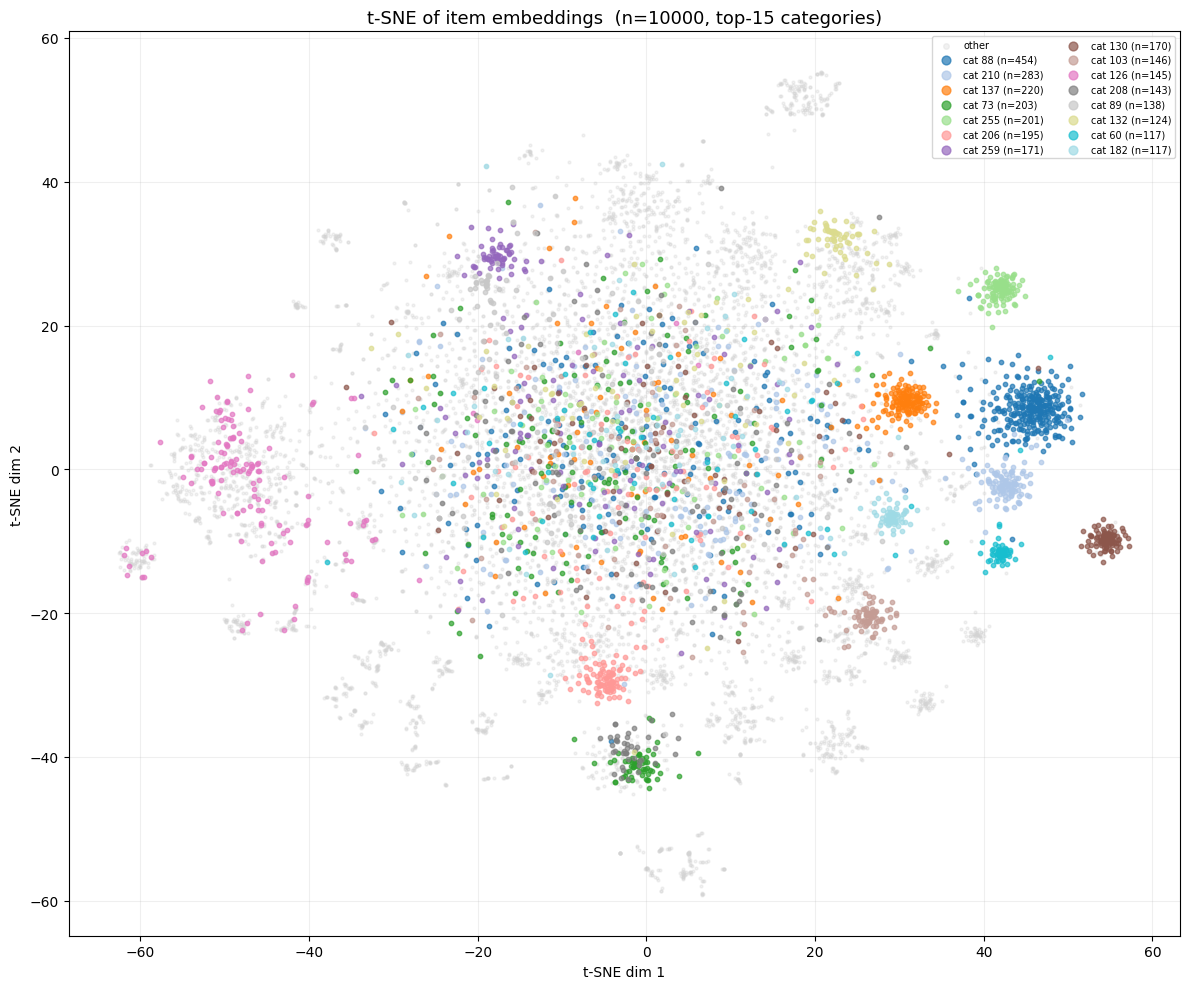

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE

N_ITEMS = 10000
TOP_K_CATS = 15
TSNE_PERP = 40
RANDOM_SEED = 42

all_ids = torch.arange(1, agent.item_dim + 1)
cats_all = item_cat_tensor[all_ids].cpu()
valid = (cats_all > 0).nonzero(as_tuple=True)[0]

rng = np.random.default_rng(RANDOM_SEED)
sample_i = rng.choice(len(valid), size=min(N_ITEMS, len(valid)), replace=False)
sampled_positions = valid[sample_i]
sampled_ids = all_ids[sampled_positions]
sampled_cats = cats_all[sampled_positions].numpy()

agent.eval()
with torch.no_grad():
    embs = agent.embedding(sampled_ids.to(device)).cpu().numpy()  # [N, H]

print(f"Running t-SNE on {len(embs)} items (dim={embs.shape[1]})...")
tsne = TSNE(n_components=2, perplexity=TSNE_PERP, random_state=RANDOM_SEED,
              n_iter=1000, verbose=1)
coords = tsne.fit_transform(embs) # [N, 2]
print("Done.")

unique_cats, counts = np.unique(sampled_cats, return_counts=True)
top_cats = unique_cats[np.argsort(-counts)][:TOP_K_CATS]

cmap = cm.get_cmap('tab20', TOP_K_CATS)
cat2col = {cat: cmap(i) for i, cat in enumerate(top_cats)}
colors = [cat2col.get(c, (0.7, 0.7, 0.7, 0.3)) for c in sampled_cats]

fig, ax = plt.subplots(figsize=(12, 10))

other_mask = np.array([c not in cat2col for c in sampled_cats])
ax.scatter(coords[other_mask, 0], coords[other_mask, 1],
           c='lightgray', s=4, alpha=0.3, label='other', zorder=1)

for cat in top_cats:
    mask = (sampled_cats == cat)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[cat2col[cat]], s=10, alpha=0.7,
               label=f'cat {int(cat)} (n={mask.sum()})', zorder=2)

ax.set_title(f't-SNE of item embeddings  (n={len(embs)}, top-{TOP_K_CATS} categories)',
             fontsize=13)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(loc='upper right', fontsize=7, markerscale=2,
          ncol=2, framealpha=0.8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [236]:
torch.save(agent.embedding.state_dict(), 'iql_item_embeddings_good_tsne.pt')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy

class IQLAgent(nn.Module):
    def __init__(self, item_dim, hidden_dim=64, padding_idx=0):
        super().__init__()
        self.padding_idx = padding_idx
        self.item_dim = item_dim

        self.embedding = nn.Embedding(item_dim + 1, hidden_dim, padding_idx=padding_idx)
        self.item_encoder = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        state_dim = hidden_dim

        self.v_net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
        )
        self.q_net = nn.Sequential(
            nn.Linear(state_dim + hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
        )
        self.q_target = copy.deepcopy(self.q_net)
        for p in self.q_target.parameters():
            p.requires_grad = False

        # self.policy_head = nn.Sequential(
        #     nn.Linear(state_dim, hidden_dim),
        #     nn.ReLU(),
        #     nn.Linear(hidden_dim, hidden_dim, bias=False)
        # )

        self.register_buffer('item_categories', torch.zeros(item_dim + 1, dtype=torch.long))

    def get_state_repr(self, states_seq):
        item_emb = self.embedding(states_seq)
        _, h = self.item_encoder(item_emb)
        return h.squeeze(0)

    def score_candidates(self, state_emb, candidates):
        cand_emb = self.embedding(candidates)
        s_exp = state_emb.unsqueeze(1).expand_as(cand_emb)
        scores = self.q_net(torch.cat([s_exp, cand_emb], dim=-1)).squeeze(-1)
        return scores.masked_fill(candidates == self.padding_idx, float('-inf'))

    def sync_target(self, alpha=0.005):
        for p, tp in zip(self.q_net.parameters(), self.q_target.parameters()):
            tp.data.copy_(alpha * p.data + (1 - alpha) * tp.data)

In [ ]:
def train_step(agent, batch, optimizer_v, optimizer_q,
                 gamma=0.99, tau=0.8, beta=3.0, alpha=0.005):
      with torch.no_grad():
          s_emb = agent.get_state_repr(batch['state'])
          a_emb = agent.embedding(batch['action'])
          q_hat = agent.q_target(torch.cat([s_emb, a_emb], dim=-1)).squeeze(-1)

      v_val  = agent.v_net(s_emb)
      v_loss = expectile_loss(q_hat - v_val, tau=tau)
      optimizer_v.zero_grad(); v_loss.backward()
      torch.nn.utils.clip_grad_norm_(agent.v_net.parameters(), 1.0)
      optimizer_v.step()

      s_emb = agent.get_state_repr(batch['state'])
      a_emb = agent.embedding(batch['action'])
      with torch.no_grad():
          ns_emb = agent.get_state_repr(batch['next_state'])
          next_v = agent.v_net(ns_emb)
          normed_r = batch['reward'].view(-1) * (1 - gamma)
          q_backup = normed_r + gamma * (1 - batch['terminal'].view(-1)) * next_v.squeeze(-1)
      q_val  = agent.q_net(torch.cat([s_emb, a_emb], dim=-1)).squeeze(-1)
      q_loss = F.mse_loss(q_val, q_backup)
      optimizer_q.zero_grad(); q_loss.backward()
      torch.nn.utils.clip_grad_norm_(agent.q_net.parameters(), 1.0)
      optimizer_q.step()
      agent.sync_target(alpha=alpha)

      with torch.no_grad():
          r_mask = batch['reward'].view(-1) > 0
          q_clicked = q_val[r_mask].mean().item()  if r_mask.any()  else 0.0
          q_other = q_val[~r_mask].mean().item() if (~r_mask).any() else 0.0

      return (v_loss + q_loss).item(), q_loss.item(), v_loss.item(), q_clicked, q_other

In [ ]:
agent = IQLAgent(item_dim, hidden_dim=128).to(device)
agent.embedding.load_state_dict(torch.load('/kaggle/working/iql_item_embeddings_good_tsne3.pt'))
agent.embedding.weight.requires_grad_(False)
agent.item_encoder.load_state_dict(torch.load('/kaggle/working/iql_item_encoder_tsne3.pt'))
# agent.item_encoder.requires_grad_(False)
agent.train()
optimizer_v = torch.optim.Adam(agent.v_net.parameters(), lr=3e-4)
# optimizer_p = torch.optim.Adam(agent.policy_head.parameters(), lr=1e-3)
optimizer_q = torch.optim.Adam([
      {'params': agent.q_net.parameters(),        'lr': 1e-4},
      {'params': agent.item_encoder.parameters(), 'lr': 1e-5},  # медленный fine-tune
  ])
losses, q_losses, v_losses, q_clicked_list, q_other_list = [], [], [], [], []
i = 0
print(f'Training with slates_len={slates_len}, item_dim={item_dim}')
NUM_EPOCHS = 3
for epoch in range(NUM_EPOCHS):
    print(f'~~~~~~EPOCH={epoch}~~~~~')
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        total_loss, q_loss, v_loss, q_clicked, q_other = train_step(
            agent, batch, optimizer_v, optimizer_q, tau=0.7, gamma=0.9, beta=1.0, alpha=0.02
        )
        losses.append(total_loss); q_losses.append(q_loss)
        v_losses.append(v_loss); q_clicked_list.append(q_clicked); q_other_list.append(q_other)
        if i % 50 == 0:
            print(f'Step {i}:', total_loss, q_loss, v_loss)
        i += 1

Training with slates_len=50000, item_dim=1245403
~~~~~~EPOCH=0~~~~~
Step 0: 0.07319469749927521 0.03140707314014435 0.04178762435913086
Step 50: 0.020645884796977043 0.011881040409207344 0.008764844387769699
Step 100: 0.01582309789955616 0.011011242866516113 0.004811855033040047
Step 150: 0.016453580930829048 0.012535600923001766 0.003917980473488569
Step 200: 0.01909562759101391 0.015581242740154266 0.003514385549351573
Step 250: 0.019926588982343674 0.01682130992412567 0.003105279989540577
Step 300: 0.021835539489984512 0.019048916175961494 0.0027866228483617306
Step 350: 0.021713823080062866 0.019249916076660156 0.0024639079347252846
Step 400: 0.02537703514099121 0.02313772775232792 0.0022393083199858665
Step 450: 0.027716312557458878 0.025556111708283424 0.002160200383514166
Step 500: 0.02548656240105629 0.023659370839595795 0.0018271906301379204
Step 550: 0.029707005247473717 0.027914106845855713 0.0017928985180333257
Step 600: 0.028517933562397957 0.02693990431725979 0.0015780291

KeyboardInterrupt: 

Text(0.5, 1.0, 'V loss')

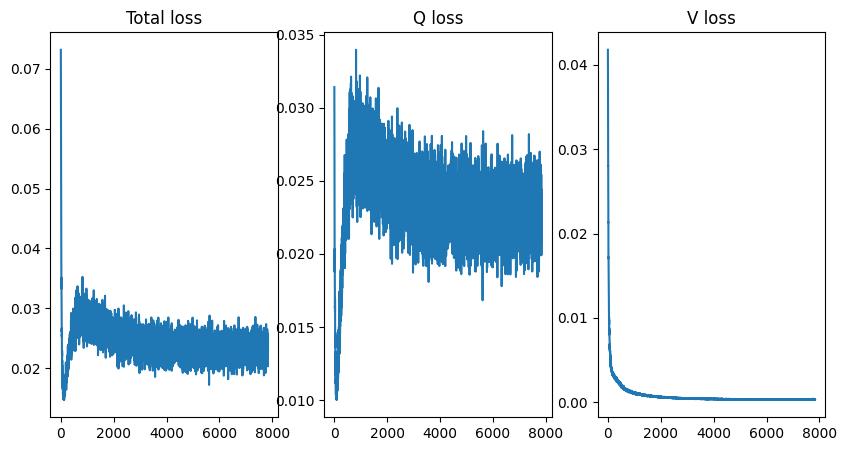

In [347]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(losses)
axes[0, 0].set_title('Total loss')
axes[0, 1].plot(q_losses)
axes[0, 1].set_title('Q loss')
axes[1, 0].plot(v_losses)
axes[1, 0].set_title('V loss')
axes[1, 1].plot(q_clicked_list, label='Q (clicked, r=1)', color='green', alpha=0.8)
axes[1, 1].plot(q_other_list,   label='Q (not clicked, r=0)', color='red', alpha=0.8)
axes[1, 1].set_title('Mean Q: reward signal')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy

class IQLAgent(nn.Module):
    def __init__(self, item_dim, num_categories,
                item_emb_dim,
                cat_emb_dim,
                hidden_dim=64, padding_idx=0):
        super().__init__()
        self.padding_idx = padding_idx
        self.item_dim = item_dim

        self.embedding = nn.Embedding(item_dim + 1, item_emb_dim, padding_idx=padding_idx)
        self.item_encoder = nn.GRU(item_emb_dim, hidden_dim, batch_first=True)

        self.cat_emb = nn.Embedding(num_categories + 2, cat_emb_dim, padding_idx=0)
        self.cat_encoder  = nn.GRU(cat_emb_dim, hidden_dim // 4, batch_first=True)

        state_dim = hidden_dim + hidden_dim // 4


        self.v_net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
        )
        self.q_net = nn.Sequential(
            nn.Linear(state_dim + hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
        )
        self.q_target = copy.deepcopy(self.q_net)
        for p in self.q_target.parameters():
            p.requires_grad = False

        # self.policy_head = nn.Sequential(
        #     nn.Linear(state_dim, hidden_dim),
        #     nn.ReLU(),
        #     nn.Linear(hidden_dim, hidden_dim, bias=False)
        # )

        self.register_buffer('item_categories', torch.zeros(item_dim + 1, dtype=torch.long))

    def get_state_repr(self, states_seq):
        item_emb = self.embedding(states_seq)
        _, h_item = self.item_encoder(item_emb)
        cat_seq  = self.item_categories[states_seq]
        cat_emb  = self.cat_emb(cat_seq)
        _, h_cat = self.cat_encoder(cat_emb)
        return torch.cat([h_item.squeeze(0), h_cat.squeeze(0)], dim=-1)

    def score_candidates(self, state_emb, candidates):
        cand_emb = self.embedding(candidates)
        s_exp = state_emb.unsqueeze(1).expand_as(cand_emb)
        scores = self.q_net(torch.cat([s_exp, cand_emb], dim=-1)).squeeze(-1)
        return scores.masked_fill(candidates == self.padding_idx, float('-inf'))

    def sync_target(self, alpha=0.005):
        for p, tp in zip(self.q_net.parameters(), self.q_target.parameters()):
            tp.data.copy_(alpha * p.data + (1 - alpha) * tp.data)

In [ ]:
def transfer_from_reward_model(agent, reward_model, freeze=True):
      transferred = []

      if agent.embedding.weight.shape == reward_model.item_emb.weight.shape:
          agent.embedding.weight.data.copy_(reward_model.item_emb.weight.data)
          transferred.append('embedding')
      else:
          print(f"embedding shape mismatch: "
                f"{agent.embedding.weight.shape} vs {reward_model.item_emb.weight.shape}")

      try:
          agent.item_encoder.load_state_dict(reward_model.encoder_items.state_dict())
          transferred.append('item_encoder')
      except Exception as e:
          print(f"item_encoder mismatch: {e}")

      try:
          agent.cat_emb.load_state_dict(reward_model.cat_emb.state_dict())
          transferred.append('cat_emb')
      except Exception as e:
          print(f"cat_emb mismatch: {e}")

      try:
          agent.cat_encoder.load_state_dict(reward_model.encoder_cats.state_dict())
          transferred.append('cat_encoder')
      except Exception as e:
          print(f"cat_encoder mismatch: {e}")

      if freeze:
          for name in transferred:
              module = getattr(agent, name)
              for p in module.parameters():
                  p.requires_grad_(False)

      print(f"Transferred and frozen: {transferred}")

In [ ]:
reward_model.eval()
item_emb_dim = reward_model.item_emb.embedding_dim
cat_emb_dim  = reward_model.cat_emb.embedding_dim

agent = IQLAgent(
  item_dim=item_dim,
  num_categories=num_categories,
  item_emb_dim=item_emb_dim,
  cat_emb_dim=cat_emb_dim,
  hidden_dim=128
).to(device)

transfer_from_reward_model(agent, reward_model, freeze=True)
# agent.embedding.load_state_dict(torch.load('/kaggle/working/iql_item_embeddings_good_tsne3.pt'))
# agent.embedding.weight.requires_grad_(False)
# agent.item_encoder.load_state_dict(torch.load('/kaggle/working/iql_item_encoder_tsne3.pt'))
# agent.item_encoder.requires_grad_(False)
optimizer_v = torch.optim.Adam(agent.v_net.parameters(), lr=3e-4)
# optimizer_p = torch.optim.Adam(agent.policy_head.parameters(), lr=1e-3)
optimizer_q = torch.optim.Adam([
      {'params': agent.q_net.parameters(),        'lr': 1e-4},
      {'params': agent.item_encoder.parameters(), 'lr': 1e-5},  # медленный fine-tune
  ])
losses, q_losses, v_losses, q_clicked_list, q_other_list = [], [], [], [], []
i = 0
print(f'Training with slates_len={slates_len}, item_dim={item_dim}')
NUM_EPOCHS = 3
for epoch in range(NUM_EPOCHS):
    print(f'~~~~~~EPOCH={epoch}~~~~~')
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        total_loss, q_loss, v_loss, q_clicked, q_other = train_step(
            agent, batch, optimizer_v, optimizer_q, tau=0.7, gamma=0.9, beta=1.0, alpha=0.02
        )
        losses.append(total_loss); q_losses.append(q_loss)
        v_losses.append(v_loss); q_clicked_list.append(q_clicked); q_other_list.append(q_other)
        if i % 50 == 0:
            print(f'Step {i}:', total_loss, q_loss, v_loss)
        i += 1

Transferred and frozen: ['embedding', 'item_encoder', 'cat_emb', 'cat_encoder']
Training with slates_len=50000, item_dim=1245403
~~~~~~EPOCH=0~~~~~
Step 0: 0.27429673075675964 0.11994889378547668 0.15434783697128296
Step 50: 0.0373600535094738 0.02545429766178131 0.011905754916369915
Step 100: 0.03608400747179985 0.027304701507091522 0.008779305964708328
Step 150: 0.03123404271900654 0.023551182821393013 0.007682859897613525
Step 200: 0.030856117606163025 0.023688904941082 0.0071672117337584496
Step 250: 0.028076494112610817 0.021372966468334198 0.006703527644276619
Step 300: 0.030365750193595886 0.023232437670230865 0.007133311592042446
Step 350: 0.03183871507644653 0.02427745796740055 0.007561255246400833
Step 400: 0.03154328465461731 0.02452685497701168 0.007016431074589491
Step 450: 0.032686084508895874 0.025342434644699097 0.007343651726841927
Step 500: 0.0321817547082901 0.02487119659781456 0.00731055811047554
Step 550: 0.030793840065598488 0.024135231971740723 0.0066586076281964

KeyboardInterrupt: 

Text(0.5, 1.0, 'V loss')

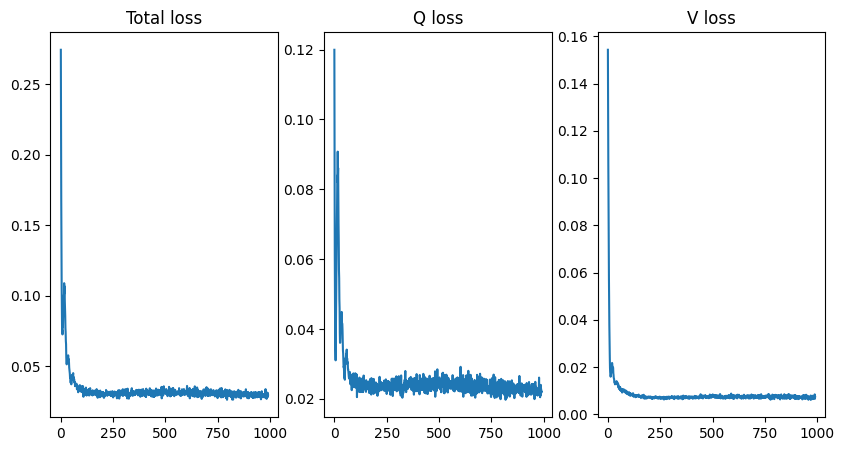

In [363]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(losses)
axes[0, 0].set_title('Total loss')
axes[0, 1].plot(q_losses)
axes[0, 1].set_title('Q loss')
axes[1, 0].plot(v_losses)
axes[1, 0].set_title('V loss')
axes[1, 1].plot(q_clicked_list, label='Q (clicked, r=1)', color='green', alpha=0.8)
axes[1, 1].plot(q_other_list,   label='Q (not clicked, r=0)', color='red', alpha=0.8)
axes[1, 1].set_title('Mean Q: reward signal')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

In [371]:
evaluate_ranking_metrics(agent, dat, item2id, 2000, 5, 25) # using rerank_sequential

100%|██████████| 2000/2000 [03:27<00:00,  9.64it/s]

HitRate@5: 0.5390
NDCG@5:    0.3187


{'HitRate@5': np.float64(0.5389865802869042),
 'NDCG@5': np.float64(0.31871393952818367)}

In [ ]:
reward_model.eval()
item_emb_dim = reward_model.item_emb.embedding_dim
cat_emb_dim  = reward_model.cat_emb.embedding_dim

agent = IQLAgent(
  item_dim=item_dim,
  num_categories=num_categories,
  item_emb_dim=item_emb_dim,
  cat_emb_dim=cat_emb_dim,
  hidden_dim=128
).to(device)

transfer_from_reward_model(agent, reward_model, freeze=True)
# agent.embedding.load_state_dict(torch.load('/kaggle/working/iql_item_embeddings_good_tsne3.pt'))
# agent.embedding.weight.requires_grad_(False)
# agent.item_encoder.load_state_dict(torch.load('/kaggle/working/iql_item_encoder_tsne3.pt'))
# agent.item_encoder.requires_grad_(False)
optimizer_v = torch.optim.Adam(agent.v_net.parameters(), lr=3e-4)
# optimizer_p = torch.optim.Adam(agent.policy_head.parameters(), lr=1e-3)
optimizer_q = torch.optim.Adam([
      {'params': agent.q_net.parameters(),        'lr': 1e-4},
      {'params': agent.item_encoder.parameters(), 'lr': 1e-5},  # медленный fine-tune
  ])
losses, q_losses, v_losses, q_clicked_list, q_other_list = [], [], [], [], []
i = 0
print(f'Training with slates_len={slates_len}, item_dim={item_dim}')
NUM_EPOCHS = 3
for epoch in range(NUM_EPOCHS):
    print(f'~~~~~~EPOCH={epoch}~~~~~')
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        total_loss, q_loss, v_loss, q_clicked, q_other = train_step(
            agent, batch, optimizer_v, optimizer_q, tau=0.7, gamma=0.9, beta=1.0, alpha=0.02
        )
        losses.append(total_loss); q_losses.append(q_loss)
        v_losses.append(v_loss); q_clicked_list.append(q_clicked); q_other_list.append(q_other)
        if i % 500 == 0:
            print(f'Step {i}:', total_loss, q_loss, v_loss)
        i += 1

Transferred and frozen: ['embedding', 'item_encoder', 'cat_emb', 'cat_encoder']
Training with slates_len=50000, item_dim=1245403
~~~~~~EPOCH=0~~~~~
Step 0: 0.10216999799013138 0.08053964376449585 0.02163035422563553
Step 500: 0.02151571959257126 0.016760729253292084 0.004754991270601749
Step 1000: 0.02402825839817524 0.018280362710356712 0.005747895687818527
Step 1500: 0.02845798432826996 0.021792668849229813 0.006665315479040146
Step 2000: 0.02471247874200344 0.018554242327809334 0.006158236414194107
Step 2500: 0.02568419836461544 0.018319832161068916 0.007364366203546524
Step 3000: 0.023711811751127243 0.017417998984456062 0.006293811835348606
~~~~~~EPOCH=1~~~~~
Step 3500: 0.020621633157134056 0.015041902661323547 0.005579730495810509
Step 4000: 0.022543370723724365 0.016160456463694572 0.006382914260029793
Step 4500: 0.024057716131210327 0.016908932477235794 0.007148783188313246
Step 5000: 0.021136604249477386 0.014250373467803001 0.00688623171299696
Step 5500: 0.022234298288822174 

KeyboardInterrupt: 

Text(0.5, 1.0, 'V loss')

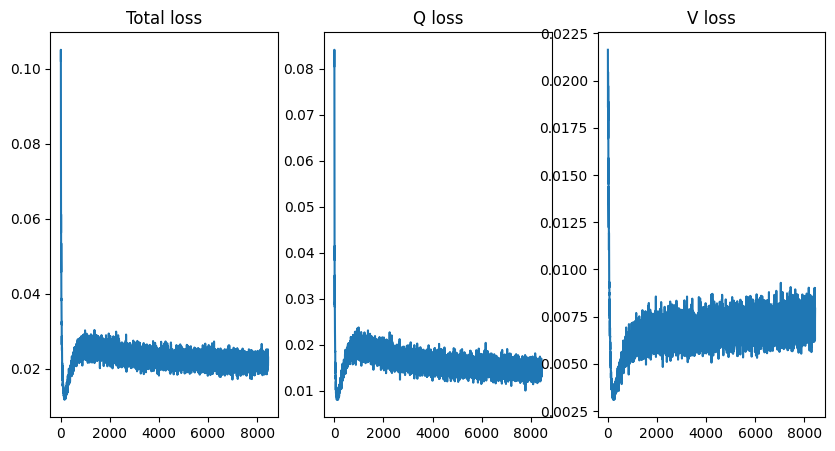

In [374]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(losses)
axes[0, 0].set_title('Total loss')
axes[0, 1].plot(q_losses)
axes[0, 1].set_title('Q loss')
axes[1, 0].plot(v_losses)
axes[1, 0].set_title('V loss')
axes[1, 1].plot(q_clicked_list, label='Q (clicked, r=1)', color='green', alpha=0.8)
axes[1, 1].plot(q_other_list,   label='Q (not clicked, r=0)', color='red', alpha=0.8)
axes[1, 1].set_title('Mean Q: reward signal')
axes[1, 1].legend()
plt.tight_layout()
plt.show()